# 10. Проверяем стекинг и Optuna

До этого мы усредняли ранги трёх CatBoost. Теперь дадим их оценки четвёртой модели и проверим, сможет ли она смешать их лучше. Подберём параметры через Optuna. Но сначала договоримся о проверке: разница в метрике имеет смысл только на днях, которые не участвовали в подборе

## Как устроена проверка

Для верхней модели нужны предсказания базовых моделей на знакомых нам куках. Если взять оценки тех же кук, на которых базовые модели учились, верхняя модель увидит слишком лёгкую картину. Поэтому для каждого блока мы заново обучаем три нижние модели только на более ранних днях.

| Дни | Что делаем |
| --- | --- |
| 9–10 и 11–13 апреля | Подбираем параметры трёх нижних CatBoost. Каждый раз обучение заканчивается до проверяемого блока. |
| 9–16 апреля | Получаем предсказания для обучения верхнего CatBoost. Optuna подбирает его параметры по ранним блокам. |
| 17–19 апреля | Один отложенный блок для сравнения со старым ответом. Его метки в подборе не участвуют. |
| 20–26 апреля | Тест без меток. Для него считаем итоговые оценки после выбора решения. |

Верхняя модель видит шесть чисел: три исходных `score` и три процентильных ранга этих `score` внутри блока. Ранги помогают, если шкалы у нижних моделей отличаются. Обратная сторона та же, что у прежнего среднего рангов: результат зависит от состава партии кук.

Optuna максимизирует нашу P@R70, то есть precision при recall не ниже 70%. На ранних блоках это всего лишь инструмент подбора, а не честная оценка качества. Особенно 11–13 апреля: эти метки уже участвовали в подборе нижних моделей

In [1]:
from pathlib import Path
import os
import sys
import json

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "run_stacking.py").exists())
os.chdir(root)
sys.path.insert(0, str(root))

from run_stacking import main

## Воспроизводим опыт

Параметры последнего поиска лежат в `stacking_params.json`. Я оставил их в проекте, чтобы обычный запуск не тратил время на Optuna и давал тот же результат. Если хочется провести поиск заново, поменяй `TUNE_AGAIN` на `True`. Seed зафиксирован

In [2]:
TUNE_AGAIN = False
main(tune=TUNE_AGAIN, base_trials=16, meta_trials=24)

17–19 апреля, отложенные дни:
                        model  p_at_r70
        Старое среднее рангов  0.805755
Новые базовые, среднее рангов  0.783217
         CatBoost поверх трёх  0.777778


Готово: output/stacked_submission.csv (4909 кук)


In [3]:
params = json.loads((root / "stacking_params.json").read_text())
rows = [{"модель": name, **values} for name, values in params["base"].items()]
rows.append({"модель": "верхний CatBoost", **params["meta"]})
display(pd.DataFrame(rows).round(4))

,модель,iterations,depth,learning_rate,l2_leaf_reg
0,base_plus,500,6,0.0474,3.7926
1,routes_plus,500,6,0.0628,8.1247
2,context_plus,800,4,0.0327,2.9926
3,верхний CatBoost,350,2,0.0329,6.0113


## Сравниваем на последних трёх днях

Здесь все варианты проверяются на одних и тех же куках 17–19 апреля. Столбец со старым средним рангов берётся из сохранённой проверки предыдущего решения. Он нужен как ориентир. Для нового стекинга нижние модели обучены на прошлом, а верхняя видела только предсказания за 9–16 апреля

,model,p_at_r70
0,Старое среднее рангов,0.806
1,"Новые базовые, среднее рангов",0.783
2,CatBoost поверх трёх,0.778


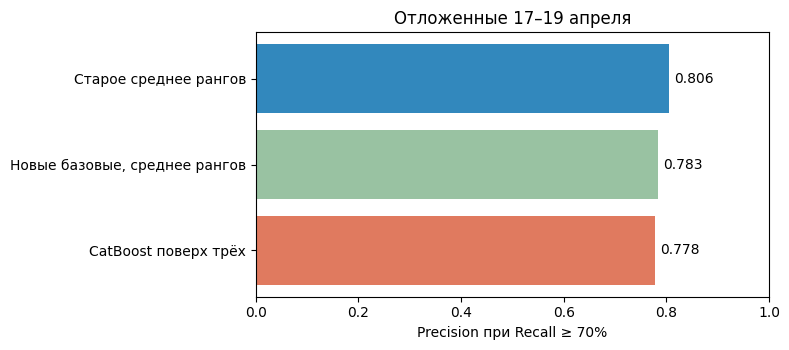

In [4]:
comparison = pd.read_csv(root / "output" / "stacking_comparison.csv")
display(comparison.style.format({"p_at_r70": "{:.3f}"}))

fig, ax = plt.subplots(figsize=(8, 3.6))
colors = ["#3288bd", "#99c2a2", "#e07a5f"][:len(comparison)]
ax.barh(comparison["model"], comparison["p_at_r70"], color=colors)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("Precision при Recall ≥ 70%")
ax.set_title("Отложенные 17–19 апреля")
for i, value in enumerate(comparison["p_at_r70"]):
    ax.text(value + .01, i, f"{value:.3f}", va="center")
plt.tight_layout()
plt.show()

In [5]:
holdout = pd.read_csv(root / "output" / "stacking_holdout_scores.csv")
score_columns = ["base_plus", "routes_plus", "context_plus", "rank_mean", "stacked_score"]
display(holdout[score_columns].corr(method="spearman").round(3))
print(f"Отложено кук: {len(holdout)}, среди них ботов: {holdout.target.sum()}")

,base_plus,routes_plus,context_plus,rank_mean,stacked_score
base_plus,1.000,0.964,0.962,0.987,0.983
routes_plus,0.964,1.000,0.966,0.989,0.980
context_plus,0.962,0.966,1.000,0.988,0.971
rank_mean,0.987,0.989,0.988,1.000,0.990
stacked_score,0.983,0.980,0.971,0.990,1.000


Отложено кук: 1951, среди них ботов: 160


## Что вышло

На отложенных 17–19 апреля прежнее среднее рангов получило **0,806**, среднее рангов новых нижних моделей после Optuna **0,783**, а CatBoost поверх их оценок **0,778**. Значит, на этой проверке усложнение не окупилось. Мы не получили оснований заменить ансамбль без Word2Vec.

Нижние модели очень похожи: попарная корреляция их рангов выше 0,96. Верхнему бустингу почти нечего извлекать из трёх похожих оценок. Его порядок кук тоже почти совпадает со средним рангов, но около порога для 70% recall небольших перестановок хватило, чтобы precision снизился.

Число 0,806 относится только к последнему блоку. У прежнего решения среднее по трём проверкам **0,725**. Для нового стека нельзя честно заявлять среднее по тем же трём блокам: ранние дни участвовали в подборе. На скрытом тесте качество пока неизвестно

## Что осталось от опыта

Скрипт сохраняет результат стекинга в `output/stacked_submission.csv`. На отложенных днях четвёртая модель уступила простому среднему рангов, поэтому для финального ответа её не взяли. Позже, в ноутбуке 13, мы выбрали другой вариант. Качество на скрытом тесте по-прежнему неизвестно

In [6]:
candidate = pd.read_csv(root / "output" / "stacked_submission.csv")
original = pd.read_csv(root / "data" / "test.csv")
assert candidate.columns.tolist() == ["cookie_id", "score"]
assert candidate.cookie_id.equals(original.cookie_id)
assert candidate.score.between(0, 1).all()
print(f"Кук: {len(candidate)}; пропусков score: {candidate.score.isna().sum()}")

Кук: 4909; пропусков score: 0
